In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"

In [3]:
import h5py

sample_idx = 3 #21
bc_sample = 0.0 # u(x) = 0 on the boundary
beta = 10.0     # Force term f(x)

with h5py.File(FILE_PATH, 'r') as f:
    x_coords = np.array(f['x-coordinate'][:])
    y_coords = np.array(f['y-coordinate'][:])
    a_sample = jnp.array(f['nu'][sample_idx])
    u_raw = jnp.array(f['tensor'][sample_idx])

# Squeeze out the extra dimension
u_sample = u_raw.squeeze()

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Solution 'u' Shape: {u_flat.shape}")

E0721 01:10:00.591845  424322 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0721 01:10:00.671952  424211 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


Spatial Field 'a' Shape: (16384, 1)
Solution 'u' Shape: (16384, 1)


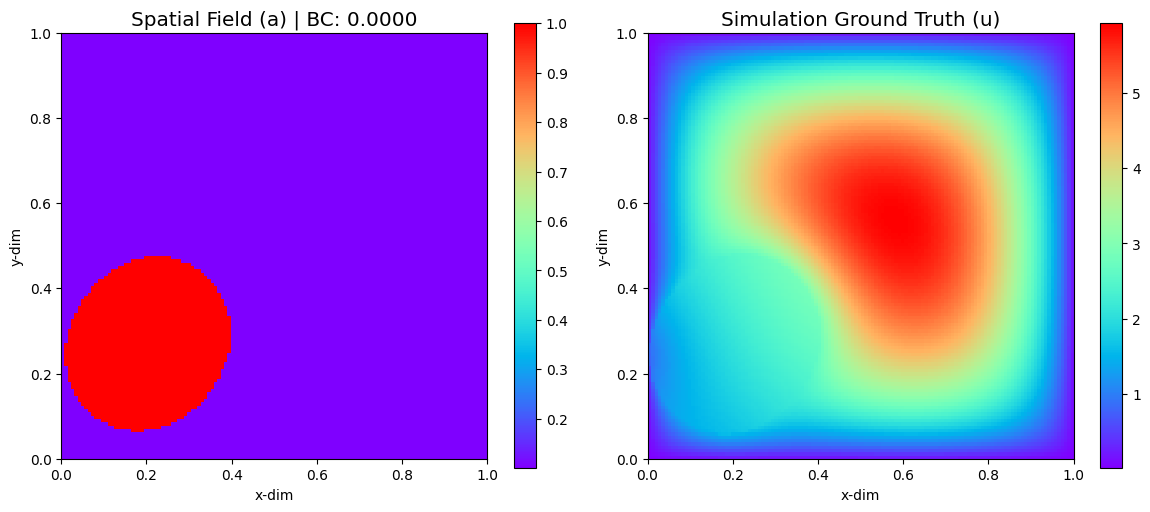

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(a_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im1, ax=axes[0])
axes[0].set_title(f'Spatial Field (a) | BC: {bc_sample:.4f}', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

im2 = axes[1].imshow(u_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [ ]:
# Smooth the a(x,y)

from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator

nx = len(x_coords) 
ny = len(y_coords) 

scale_factor = 1 # Doubles the grid resolution (more points in the solve)
fine_nx, fine_ny = nx * scale_factor, ny * scale_factor

x_l, x_u = float(np.min(x_coords)), float(np.max(x_coords)) 
y_l, y_u = float(np.min(y_coords)), float(np.max(y_coords)) 

fine_x_coords = np.linspace(x_l, x_u, fine_nx)
fine_y_coords = np.linspace(y_l, y_u, fine_ny)
X_fine, Y_fine = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')

x = jnp.array(X_fine.reshape(-1, 1))
y = jnp.array(Y_fine.reshape(-1, 1))

a_sample_np = np.array(a_sample)
interp_a = RegularGridInterpolator((x_coords, y_coords), a_sample_np, method='nearest')
a_sample_fine = interp_a((X_fine, Y_fine))
a_sample_smoothed = jnp.array(gaussian_filter(a_sample_fine, sigma=scale_factor))

# Calculate spatial gradients on the smoothed field
h_x_fine = fine_x_coords[1] - fine_x_coords[0]
h_y_fine = fine_y_coords[1] - fine_y_coords[0]
da_dx, da_dy = jnp.gradient(a_sample_smoothed, h_x_fine, h_y_fine)

a_flat_smooth = a_sample_smoothed.reshape(-1, 1)
a_x_flat = da_dx.reshape(-1, 1)
a_y_flat = da_dy.reshape(-1, 1)

# Interpolate ground truth 'u' to fine grid
u_sample_np = np.array(u_sample)
interp_u = RegularGridInterpolator((x_coords, y_coords), u_sample_np, method='linear')
u_sample_fine = interp_u((X_fine, Y_fine))

# Because the original grid is cell-centered, ALL of the interpolated points are interior points
x_valid = x
y_valid = y
a_valid = a_flat_smooth
a_x_valid = a_x_flat
a_y_valid = a_y_flat
u_valid = jnp.array(u_sample_fine.reshape(-1, 1))

# Generate True Mathematical Boundaries at (0,1)^2 dynamically
edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

# Enforce exactly u=0.0 on these boundaries
bc_val_array = jnp.zeros_like(x_bc)

print(f"Total interior grid points: {x.shape[0]}")
print(f"Boundary constraint points generated: {x_bc.shape[0]}")

Total interior grid points: 16384
Boundary constraint points generated: 512


In [6]:
epochs = 600
M = 512 
chunk_size = 256 
hidden_layers = [256, 256, 256, 256] 
total_features = hidden_layers[-1]

sigma = 1
tik_reg_fixed = 1e-8
matrix_bc_weight = 1e2
pde_loss_weight = 1.0
bc_loss_weight = 1e2
data_loss_weight = 0

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
        return h 

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)
key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_x, f_y, f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_x_chunk = jacfwd(get_f_chunk, argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_y_chunk = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_x_chunk = jnp.squeeze(f_x_chunk, axis=-1)
    f_y_chunk = jnp.squeeze(f_y_chunk, axis=-1)
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_x_chunk, f_y_chunk, f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_x, f_y, f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_x = jnp.dot(f_x, w_current)
    u_y = jnp.dot(f_y, w_current)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_x, u_y, u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [7]:
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=epochs, alpha=0.1)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

def get_A_and_b(params, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        f_x, f_y, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        A_pde_chunk = -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))
        
        f_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx)
        A_bc_chunk = f_bc_chunk * jnp.sqrt(matrix_bc_weight)
        
        A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
        A_chunks.append(A_chunk)
        
    A_full = jnp.hstack(A_chunks)
    
    b_pde = jnp.ones_like(a_pde) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_full = jnp.vstack([b_pde, b_bc])
    
    return A_full, b_full

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def solve_w(params, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A, b = get_A_and_b(params, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
    Atb = A.T @ b
    return jax.scipy.linalg.solve(AtA, Atb, assume_a='pos')

def compute_all_losses(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch):
    w_current = solve_w(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    # Darcy Flow PDE Residual
    pde_residual = -(a_x_batch * u_x + a_y_batch * u_y + a_batch * laplacian_u) - beta
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
    loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
    loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
    loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
    loss_data_scaled = loss_data_unscaled * data_loss_weight
    
    aux_unscaled = (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)
    return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), aux_unscaled

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    # Vector-Jacobian Product to extract individual gradient norms
    loss_tuple, vjp_fn, aux_unscaled = jax.vjp(
        lambda p: compute_all_losses(p, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch),
        params,
        has_aux=True
    )
    
    l_pde_scaled, l_bc_scaled, l_data_scaled = loss_tuple
    
    # Pull gradients for each loss individually to monitor the "seesaw"
    pde_grads = vjp_fn((1.0, 0.0, 0.0))[0]
    bc_grads = vjp_fn((0.0, 1.0, 0.0))[0]
    data_grads = vjp_fn((0.0, 0.0, 1.0))[0]
    total_grads = vjp_fn((1.0, 1.0, 1.0))[0] # Sum of all gradients
    
    total_loss = l_pde_scaled + l_bc_scaled + l_data_scaled
    
    # Update network
    updates, opt_state = optimizer.update(total_grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    # Calculate global norms for logging
    grad_norms = (
        optax.global_norm(total_grads),
        optax.global_norm(pde_grads),
        optax.global_norm(bc_grads),
        optax.global_norm(data_grads)
    )
    
    return new_params, opt_state, total_loss, aux_unscaled, grad_norms

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_valid_points = x_valid.shape[0]
actual_batch_size = 10000 

history_total = []
history_pde = []
history_bc = []
history_data = []

for epoch in tqdm(range(epochs), desc="End-to-End PINN Training"):
    rng, shuffle_key = jax.random.split(rng)
    
    batch_idx = jax.random.choice(shuffle_key, total_valid_points, shape=(actual_batch_size,), replace=True)
    
    x_chunk = x_valid[batch_idx]
    y_chunk = y_valid[batch_idx]
    a_chunk = a_valid[batch_idx]
    a_x_chunk = a_x_valid[batch_idx]
    a_y_chunk = a_y_valid[batch_idx]
    u_chunk = u_valid[batch_idx]
    
    params, opt_state, loss, (l_pde, l_bc, l_data), norms = update_network(
        params, opt_state, x_chunk, y_chunk, a_chunk, a_x_chunk, a_y_chunk, x_bc, y_bc, bc_val_array, u_chunk, total_features, chunk_size
    )
    
    history_total.append(float(loss))
    history_pde.append(float(l_pde))
    history_bc.append(float(l_bc))
    history_data.append(float(l_data))
    
    if epoch % 10 == 0:
        g_tot, g_pde, g_bc, g_data = norms
        print(f"Epoch {epoch:<3} | Tot Loss (scaled): {loss:.3e} | PDE(un): {l_pde:.3e} | BC(un): {l_bc:.3e} | Data(un): {l_data:.3e}")
        print(f"            └─ Grad Norms => Tot: {g_tot:.3e} | PDE: {g_pde:.3e} | BC: {g_bc:.3e} | Data: {g_data:.3e}")

End-to-End PINN Training:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 0   | Tot Loss (scaled): 8.300e+01 | PDE(un): 8.137e+01 | BC(un): 1.630e-02 | Data(un): 8.512e+00
            └─ Grad Norms => Tot: 1.964e+02 | PDE: 1.953e+02 | BC: 1.012e+02 | Data: 0.000e+00
Epoch 10  | Tot Loss (scaled): 5.167e+01 | PDE(un): 4.822e+01 | BC(un): 3.452e-02 | Data(un): 4.287e+00
            └─ Grad Norms => Tot: 1.309e+02 | PDE: 1.278e+02 | BC: 1.212e+02 | Data: 0.000e+00
Epoch 20  | Tot Loss (scaled): 4.351e+01 | PDE(un): 4.168e+01 | BC(un): 1.826e-02 | Data(un): 3.264e+00
            └─ Grad Norms => Tot: 1.346e+02 | PDE: 1.615e+02 | BC: 6.425e+01 | Data: 0.000e+00
Epoch 30  | Tot Loss (scaled): 3.137e+01 | PDE(un): 2.912e+01 | BC(un): 2.253e-02 | Data(un): 1.916e+00
            └─ Grad Norms => Tot: 2.819e+02 | PDE: 2.216e+02 | BC: 1.353e+02 | Data: 0.000e+00
Epoch 40  | Tot Loss (scaled): 2.297e+01 | PDE(un): 2.093e+01 | BC(un): 2.046e-02 | Data(un): 1.219e+00
            └─ Grad Norms => Tot: 3.086e+02 | PDE: 2.848e+02 | BC: 1.326e+02 | Data: 0.000e+00
Epoch

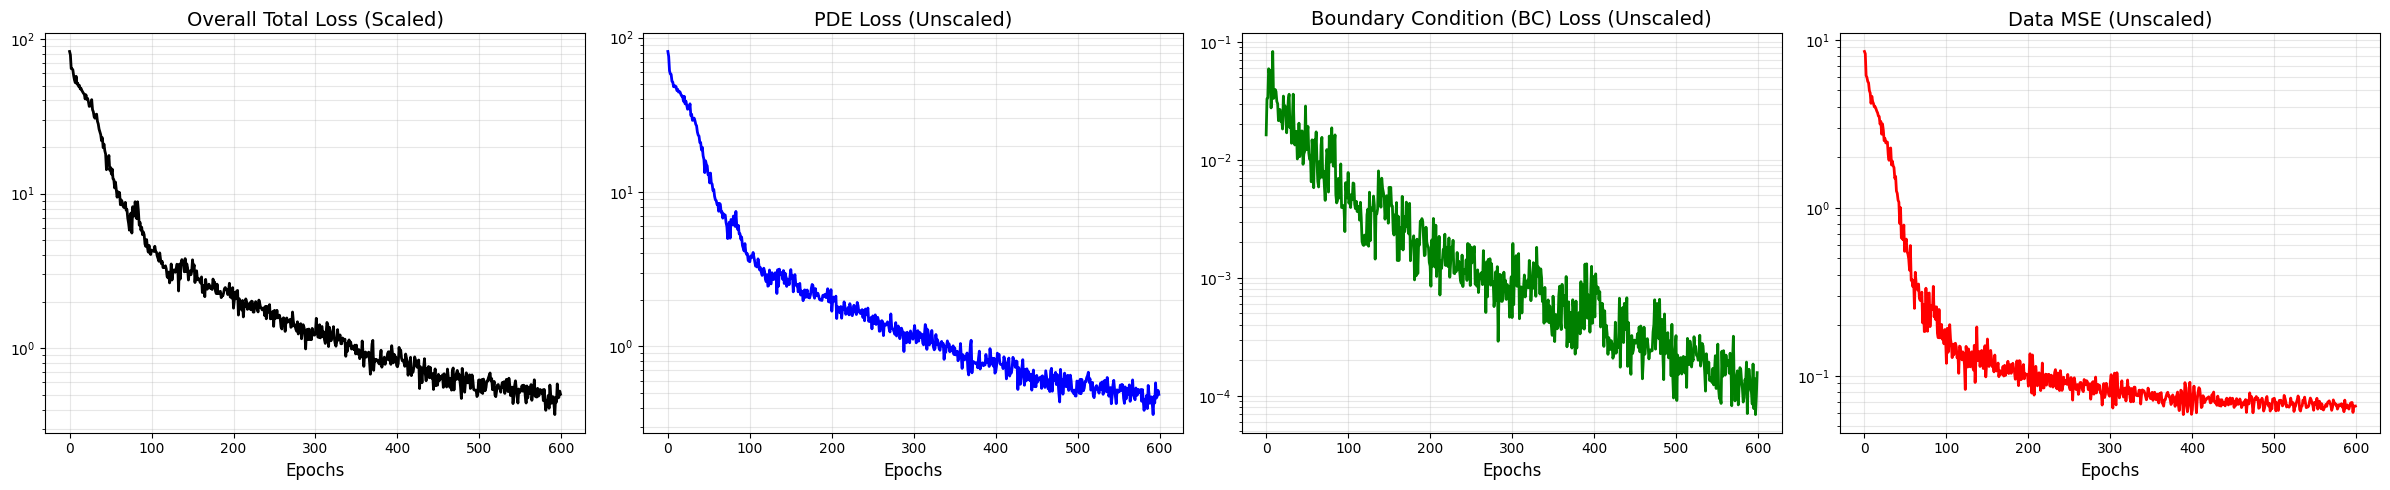

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Overall Total Loss
axes[0].plot(history_total, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_title('Overall Total Loss (Scaled)', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].grid(True, which="both", ls="-", alpha=0.3)

# PDE Loss
axes[1].plot(history_pde, color='blue', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_title('PDE Loss (Unscaled)', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].grid(True, which="both", ls="-", alpha=0.3)

# BC Loss
axes[2].plot(history_bc, color='green', linewidth=2)
axes[2].set_yscale('log')
axes[2].set_title('Boundary Condition (BC) Loss (Unscaled)', fontsize=14)
axes[2].set_xlabel('Epochs', fontsize=12)
axes[2].grid(True, which="both", ls="-", alpha=0.3)

# Data MSE
axes[3].plot(history_data, color='red', linewidth=2)
axes[3].set_yscale('log')
axes[3].set_title('Data MSE (Unscaled)', fontsize=14)
axes[3].set_xlabel('Epochs', fontsize=12)
axes[3].grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

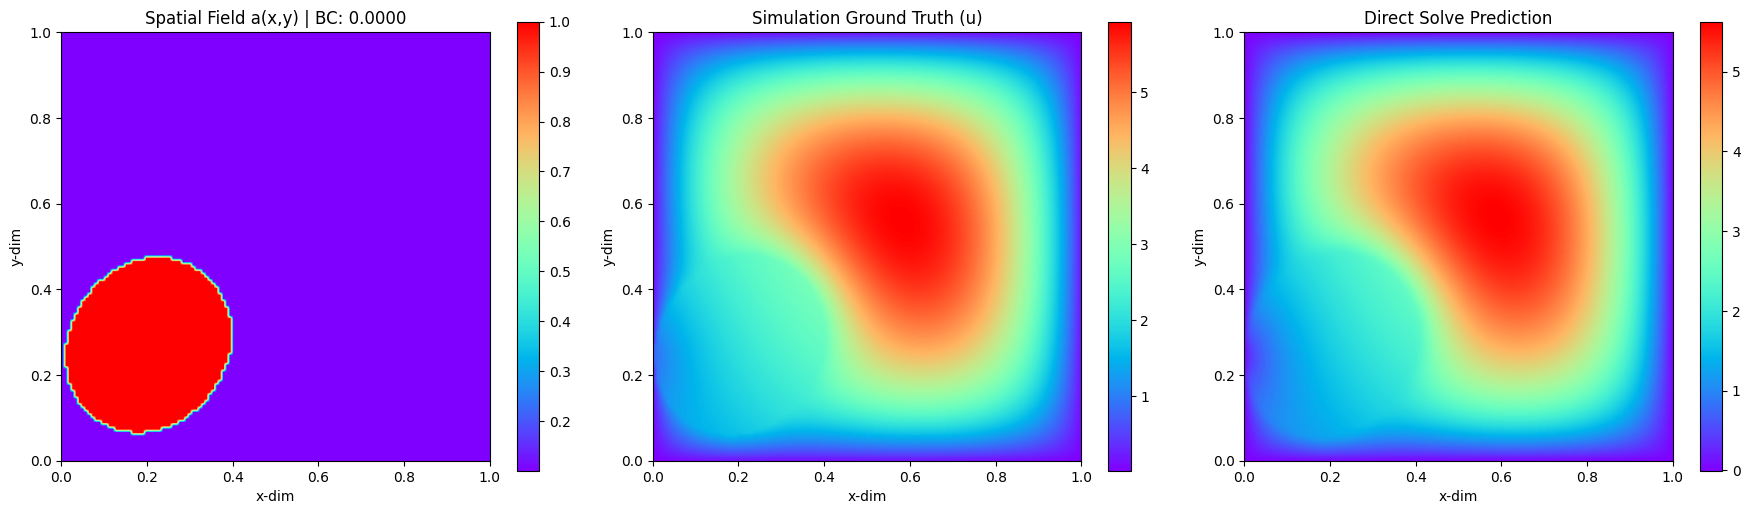

In [ ]:
# Solve for the final weights using the fine grid collocation 
w_final = solve_w(
    params, x, y, a_flat_smooth, a_x_flat, a_y_flat, 
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

# Extract features & predict for the ORIGINAL spatial grid
X_orig, Y_orig = np.meshgrid(x_coords, y_coords, indexing='ij')
x_orig = jnp.array(X_orig.reshape(-1, 1))
y_orig = jnp.array(Y_orig.reshape(-1, 1))

f_orig = f_spatial_vmap(params, x_orig, y_orig)
u_pred_orig = jnp.dot(f_orig, w_final)

# Reshape for plotting on original resolution
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_orig.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

vmin_true = float(jnp.min(u_sim_plot))
vmax_true = float(jnp.max(u_sim_plot))

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

# mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_true, vmax=vmax_true)
mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Direct Solve Prediction')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

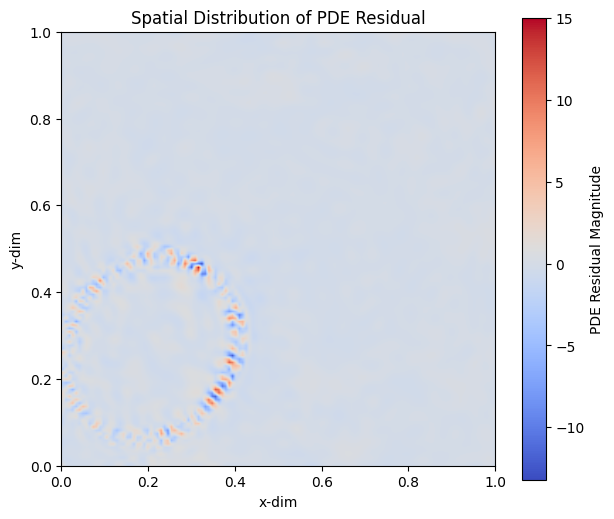

In [ ]:
def plot_jax_spatial_residual(params, w_final, x_grid, y_grid, a_grid, a_x_grid, a_y_grid):
    u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_grid, y_grid, w_final)
    laplacian_u = u_xx + u_yy
    
    pde_residual = -(a_x_grid * u_x + a_y_grid * u_y + a_grid * laplacian_u) - beta
    
    res_plot = pde_residual.reshape(fine_nx, fine_ny).T
    
    plt.figure(figsize=(7, 6))
    im = plt.imshow(res_plot, interpolation='bilinear', origin='lower', cmap='coolwarm', extent=[0, 1, 0, 1])
    plt.colorbar(im, label='PDE Residual Magnitude')
    plt.title('Spatial Distribution of PDE Residual')
    plt.xlabel('x-dim')
    plt.ylabel('y-dim')
    plt.show()

plot_jax_spatial_residual(params, w_final, x, y, a_flat_smooth, a_x_flat, a_y_flat)

In [ ]:
error_l2_norm = jnp.linalg.norm(u_pred_orig.flatten() - u_flat.flatten())
true_l2_norm = jnp.linalg.norm(u_flat.flatten())
relative_l2 = error_l2_norm / true_l2_norm

print(f"Relative L2 Error: {relative_l2:.4e} (or {relative_l2 * 100:.2f}%)")

Relative L2 Error: 8.1897e-02 (or 8.19%)
